<a href="https://colab.research.google.com/github/sagasucksatlife1/QuantProjects/blob/main/GARCH_Volatility_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
!pip install arch

In [3]:
data = yf.download('^NSEI', start = '2020-01-11', interval = "1d")['Close']
data.head()
returns = np.log(data/data.shift(1))
returns = returns * 100
returns= returns.dropna()
returns.head()

/tmp/ipykernel_1651/1639457430.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^NSEI', start = '2020-01-11', interval = "1d")['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,^NSEI
Date,
2020-01-14,0.265270
2020-01-15,-0.153811
2020-01-16,0.098792
2020-01-17,-0.025501
2020-01-20,-1.040009


First of All we import the data of daily prices from yahoo finance. Then as prices are not stationary in practice and we needed a stationar data to implement our model we converted the prices in returns by log and as the value of the returns were very low we multiplied it by 100 for rescaling purposes.

In [4]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series):
  results = adfuller(series)
  print("The adf test stats for NIFTY 50 are: ",results[0])
  print("P test value:",results[1])
  print("The number of lags used:",results[2])
  if results[1]< 0.05:
    print("The Time Series is stationary")
  else:
    print("The Time Series is not stationary")
adf_test(returns)


The adf test stats for NIFTY 50 are:  -11.589058161421493
P test value: 2.8208414572703446e-21
The number of lags used: 10
The Time Series is stationary


Just to be sure that the returns are stationary we created a function called adf_test that uses Agrumented Dickey Fuller test ... an in made library... that runs a hypothetical testing assuming that the null hypothesis is that the time Series is not stationary.

Result turned out in-favor showing that the returns are stationary over time.

PS- this entire time series turned out to be non stationary when we took the data of only a year... so work on large data..

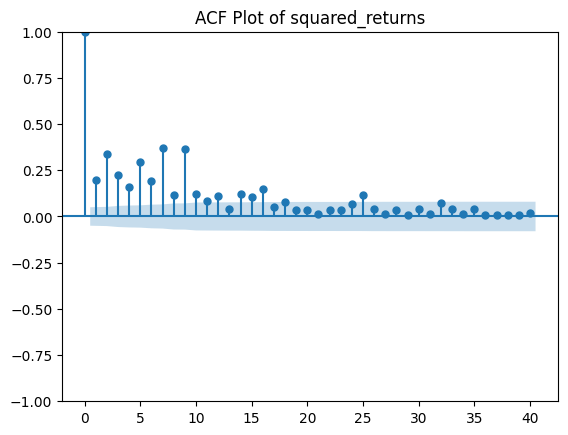

In [5]:

squared_returns = returns**2
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(squared_returns, lags=40)
plt.title("ACF Plot of squared_returns")
plt.show()



In [6]:
from statsmodels.stats.diagnostic import het_arch
def engle_arch_test(series):
  arch_test = het_arch(series)
  print("The arch test stats for NIFTY 50 are: ",arch_test[0])
  print("P value:",arch_test[1])
  if arch_test[1]< 0.05:
    print("Volatility Clustering does exist")
  else :
    print("Volatility Clustering does not exist")
engle_arch_test(returns)

The arch test stats for NIFTY 50 are:  422.1193800296463
P value: 1.8349356116343425e-84
Volatility Clustering does exist


This is the part where we check where the volatility is Clustered or not step one run a ACF test showing that the past volaitilty affects the future volatility, this gave us a graphical conformation of the Clustering.

Then we ran the statical test called Engle's ARCH test, we created the function and again though hypothetical testing landed on the result that Volatility Clustering does Exist and confirming out graphical solution.

**Again this didnt work when we took less number of samples**

In [7]:

from arch import arch_model as arch_mod_class

def run_arch_model(series, mean_type, vol_type, p_order):
     model = arch_mod_class(y=series, mean=mean_type, vol=vol_type, p=p_order)
     result_ARCH = model.fit()
     print(result_ARCH)

run_arch_model(returns,"Constant","ARCH",3)

Iteration:      1,   Func. Count:      7,   Neg. LLF: 9630.569338319223
Iteration:      2,   Func. Count:     17,   Neg. LLF: 594058.9994860544
Iteration:      3,   Func. Count:     24,   Neg. LLF: 1203252.6466211395
Iteration:      4,   Func. Count:     32,   Neg. LLF: 2220.3038140123754
Iteration:      5,   Func. Count:     39,   Neg. LLF: 2125.284693064813
Iteration:      6,   Func. Count:     47,   Neg. LLF: 2083.0849640031756
Iteration:      7,   Func. Count:     54,   Neg. LLF: 2091.8688779604818
Iteration:      8,   Func. Count:     62,   Neg. LLF: 2068.4165606963047
Iteration:      9,   Func. Count:     69,   Neg. LLF: 2068.292963212948
Iteration:     10,   Func. Count:     74,   Neg. LLF: 2068.292963212759
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2068.292963212948
            Iterations: 10
            Function evaluations: 74
            Gradient evaluations: 10
                      Constant Mean - ARCH Model Results          

After we had conformination that the data was showing clustrung and stationary , we knew that model could now be implemented. we started with the simplest of the three called ARCH Model.

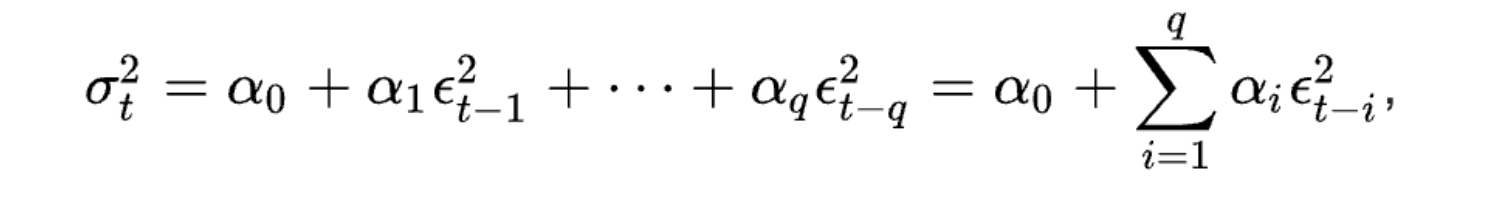


ARCH Model is model that explains how the current volatility depends on past residual..., i did calculated the residuals which is (returns - mean returns) but ended up finding out that means is so low that resuidials is roughly equal to the returns itself. it calucuted a weight foe each shock higher the weight more effect it had on the current vol... it use a MLE appoach to fing the weightage , but that happens internally.

we craeted a function and ran the arch test with order 5 that meant that the the current vol. depended on past 3 shocks only.

The key finding of the models



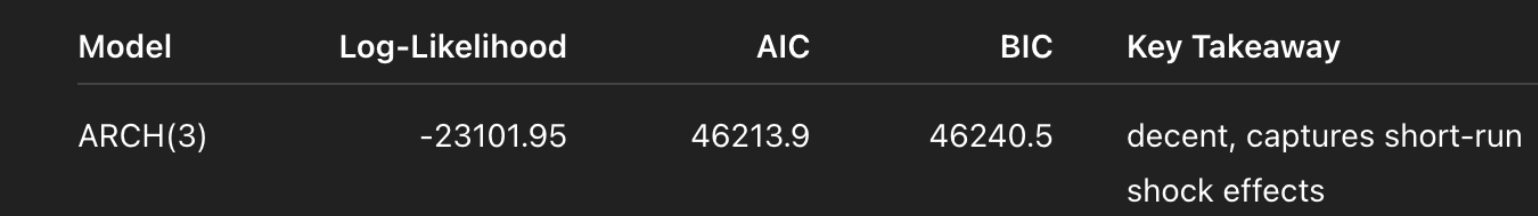

In [8]:

from arch import arch_model as arch_mod_class
def garch_model(series, mean_type, vol_type, p_order, q_order):
  model = arch_mod_class(y=series,mean = mean_type, vol = vol_type, p = p_order, q = q_order)
  result_GARCH = model.fit()
  print(result_GARCH)

garch_model(returns,"constant","GARCH",1,1)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 3345645951298.141
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1094599442.0282655
Iteration:      3,   Func. Count:     23,   Neg. LLF: 2725.9727370035407
Iteration:      4,   Func. Count:     30,   Neg. LLF: 2032.374512485416
Iteration:      5,   Func. Count:     36,   Neg. LLF: 3696.838353534036
Iteration:      6,   Func. Count:     43,   Neg. LLF: 2028.4726254202474
Iteration:      7,   Func. Count:     48,   Neg. LLF: 2028.4573274793495
Iteration:      8,   Func. Count:     53,   Neg. LLF: 2028.4571424431986
Iteration:      9,   Func. Count:     58,   Neg. LLF: 2028.4571416536369
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2028.4571416536369
            Iterations: 9
            Function evaluations: 58
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^NSEI   R-squared:         

For the second model we fitted in was GARCH model(1,1), A more modified version of the of the ARCH model it has 3 parameters omega,aplha and beta, but they are calucted internally by the library function usling MLE,

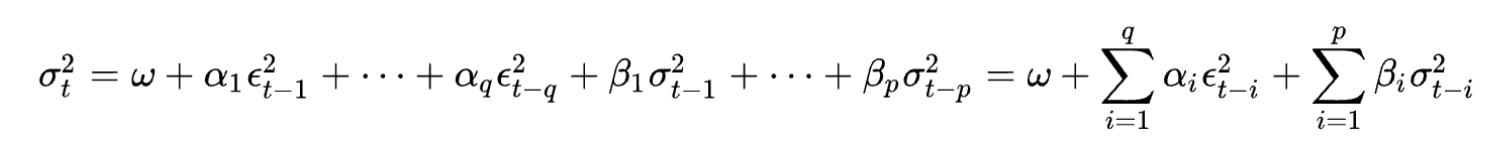

aplha= shock impact (how much does the shock impact the vol)

beta = persistence (how long vol. last)

omega= base line volatility (long term vol)

we created a function defined the order of p and q as 1 and 1. and then comapred the results.

the comaprison .... the lieklyhood has to be highest and the AIC and BIC had to be the lowest



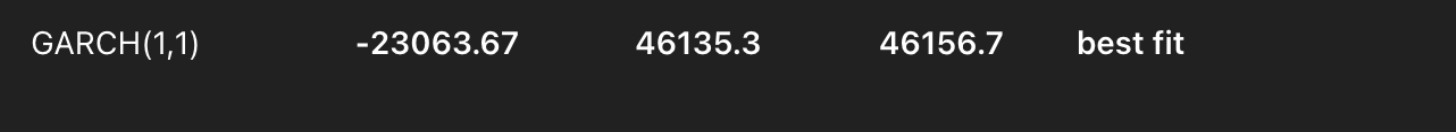

In [9]:

from arch import arch_model as arch_mod_class
def egarch_model(series,mean_type,vol_type,p_order,q_order):
  model = arch_mod_class(y = series, mean = mean_type, vol = vol_type, p = p_order, q= q_order)
  result_EGARCH = model.fit()

  return result_EGARCH

result_EGARCH = egarch_model(returns,"constant","EGARCH",1,1)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 2408219288749.6357
Iteration:      2,   Func. Count:     15,   Neg. LLF: 155705811656.11426
Iteration:      3,   Func. Count:     24,   Neg. LLF: 16575129.94529537
Iteration:      4,   Func. Count:     32,   Neg. LLF: 3346.8447948199946
Iteration:      5,   Func. Count:     40,   Neg. LLF: 2034.1080526967546
Iteration:      6,   Func. Count:     45,   Neg. LLF: 2034.1069964117162
Iteration:      7,   Func. Count:     50,   Neg. LLF: 2034.1063508513498
Iteration:      8,   Func. Count:     55,   Neg. LLF: 2034.1063264075124
Iteration:      9,   Func. Count:     59,   Neg. LLF: 2034.1063264085408
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2034.1063264075124
            Iterations: 9
            Function evaluations: 59
            Gradient evaluations: 9


the last model that we used for the caomparison is the EGARCH Model a slight more ehanaced version of the GARCH mdoel. It captures:

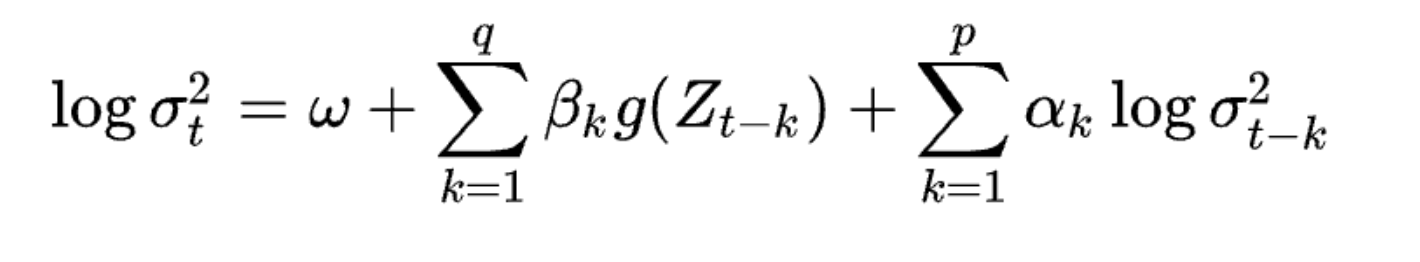


magnitude of shocks

persistence of volatility

asymmetric volatility response

As market retruns are assumed to be symmetric in the GARCH Model.


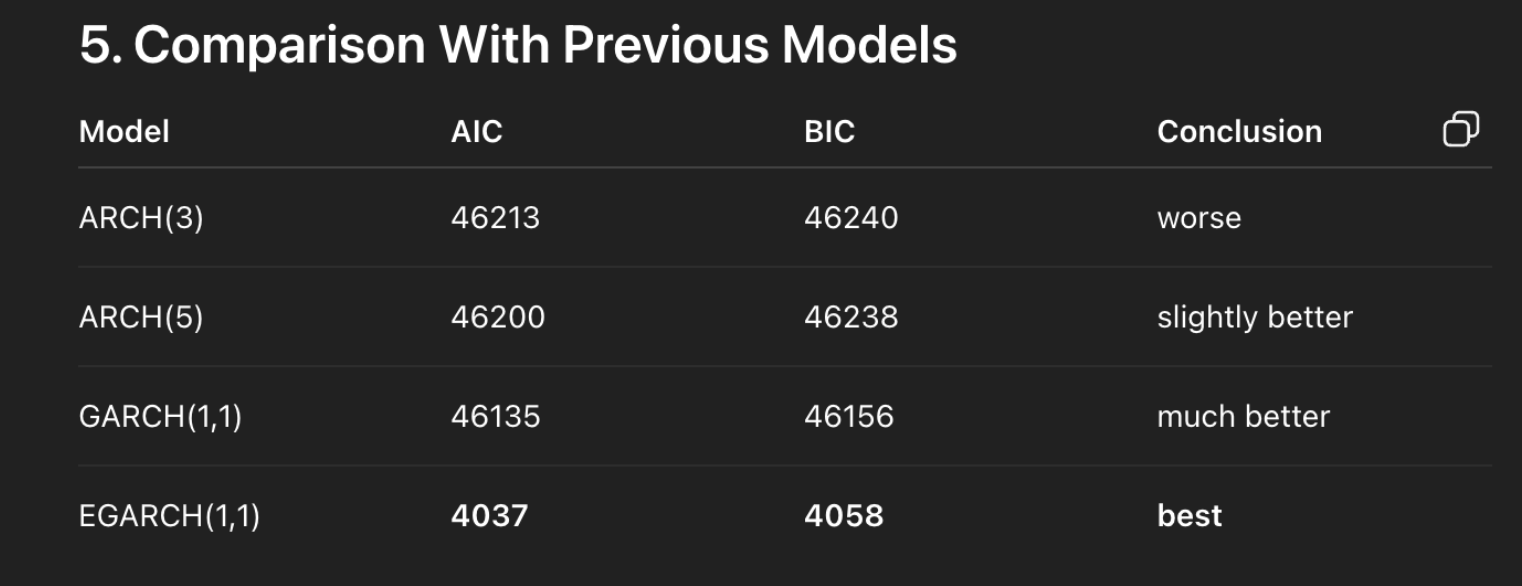

The EGARCH Model performed way better and it the best fitted when compared to the other models.

h.01    1.703390
h.02    1.699385
h.03    1.691984
h.04    1.688831
h.05    1.677250
h.06    1.672352
h.07    1.660047
h.08    1.646581
h.09    1.632933
h.10    1.617940
Name: 2026-03-24 00:00:00, dtype: float64


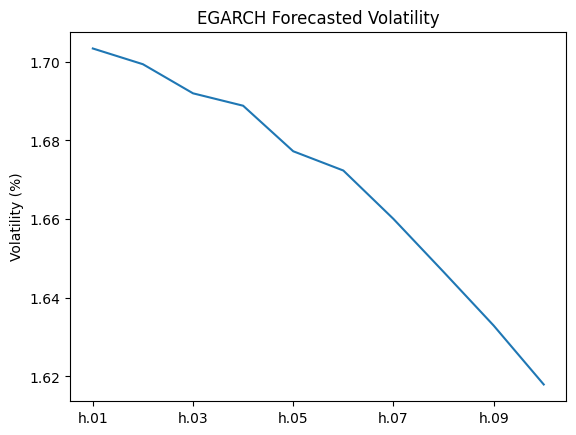

In [10]:
forecast = result_EGARCH.forecast(horizon = 10, method= 'simulation')
percicted_varience = forecast.variance.iloc[-1]
predicted_volatility = np.sqrt(percicted_varience)
print(predicted_volatility)


predicted_volatility.plot()
plt.title("EGARCH Forecasted Volatility")
plt.ylabel("Volatility (%)")
plt.show()

We thus calcuted the foecast using the EGARCH model and the VAR as well that had been claculted below.

In [11]:
def var (expected_return, predicted_volatility,confidence_interval ):
  if confidence_interval == 95 :
        var_value = expected_return + (predicted_volatility * (-1.65))
  elif confidence_interval == 99:
        var_value = expected_return + (predicted_volatility * (-2.33))

  return var_value


var(returns.mean().squeeze(),predicted_volatility,99)

,2026-03-24
h.01,-3.928784
h.02,-3.919453
h.03,-3.902210
h.04,-3.894864
h.05,-3.867878
h.06,-3.856466
h.07,-3.827795
h.08,-3.796420
h.09,-3.764621
h.10,-3.729687


Since all we used was library and we didnt use any internal funtion and working, i decided to create a GARCH Model by myself to show how thw models work internally.



First we declared a EGARCH MODEL function defined the model and that parameters and then ran a loop on the results on the likelyhood formula, and saved the results.

we returned the -(log values)

why??? cus the numpy doesnt have the maximum fuction is minimum of - log is tha max mod value.

In [12]:

import numpy as np

def egarch_model_function(params, returns):
    omega, beta, alpha, gamma = params

    returns = np.array(returns)
    T = len(returns)

    sigma2 = np.zeros(T)
    log_sigma2 = np.zeros(T)
    sigma2[0] = np.var(returns)
    log_sigma2[0] = np.log(sigma2[0])

    epsilon = returns - np.mean(returns)

    for t in range(1, T):
        z = epsilon[t-1] / np.sqrt(sigma2[t-1])

        log_sigma2[t] = (
            omega
            + beta * log_sigma2[t-1]
            + alpha * (np.abs(z) - np.sqrt(2/np.pi))
            + gamma * z
        )

        sigma2[t] = np.exp(log_sigma2[t])
    log_likelihood = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) +
        (epsilon**2) / sigma2
    )

    return -log_likelihood

In [13]:
from scipy.optimize import minimize

initial_guess = [0.01, 0.9, 0.1, -0.1]

result = minimize(
    egarch_model_function,
    initial_guess,
    args=(returns,),
    method='SLSQP'
)

print(result)

/tmp/ipykernel_1651/938587904.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_sigma2[t] = (
/tmp/ipykernel_1651/938587904.py:26: RuntimeWarning: overflow encountered in exp
  sigma2[t] = np.exp(log_sigma2[t])
/tmp/ipykernel_1651/938587904.py:17: RuntimeWarning: divide by zero encountered in divide
  z = epsilon[t-1] / np.sqrt(sigma2[t-1])
/tmp/ipykernel_1651/938587904.py:20: RuntimeWarning: invalid value encountered in add
  omega
/tmp/ipykernel_1651/938587904.py:28: RuntimeWarning: divide by zero encountered in log
  np.log(2 * np.pi * sigma2) +
/tmp/ipykernel_1651/938587904.py:29: RuntimeWarning: divide by zero encountered in divide
  (epsilon**2) / sigma2
/tmp/ipykernel_1651/938587904.py:28: RuntimeWarning: invalid value encountered in add
  np.log(2 * np.pi * sigma2) +
/tmp/ipykernel_1651/938587904.

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 3658222.2633448127
           x: [ 6.710e-02  7.564e-01 -1.555e-08 -4.976e-07]
         nit: 13
         jac: [-1.375e+00 -6.250e-01  6.875e-01 -1.344e+00]
        nfev: 97
        njev: 13
 multipliers: []


we ran the minimum fuction and set inital guess, that act as a compasrion standpoint. and printed the results.

the result didnt come out as wished and i couldnt find the error, its a mathematical error inside the model, but we did see the inner working of the project, will return once i have a little more idea about this.